# Installation

In [1]:
!git clone https://github.com/mdnestor/ide-ptws.git
%cd ide-ptws

Cloning into 'ide-ptws'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 106 (delta 4), reused 2 (delta 0), pack-reused 96
Receiving objects: 100% (106/106), 62.22 MiB | 22.36 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/ide-ptws


# Imports and growth/dispersal definition

In [2]:
import numpy as np
from ide import ide_simulate

# define (homogeneous) Ricker growth map
r = 1.0
def ricker_growth(u, x):
  return u * np.exp(r * (1 - u))

# Laplace dispersal kernel
b = 1/np.sqrt(2)
def laplace_kernel(x):
  return 1/(2*b) * np.exp(-np.abs(x)/b)

# Simulations

## Experiment 1. Hairtrigger effect with a compactly supported initial condition

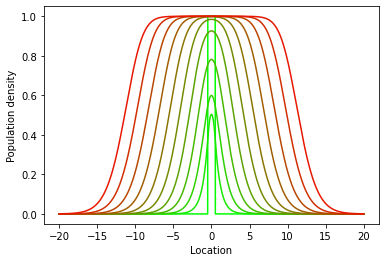

In [14]:
# define initial condition
def u0(x):
  if np.abs(x) < 0.5:
    return 1.0 # make sure to return float!
  else:
    return 0.0

# run simulation
out = ide_simulate(ricker_growth, laplace_kernel,
                       initial_cd=u0, n_iters=10,
                       xmin=-20, xmax=20, step_size=0.01)

# plot results
import matplotlib.pyplot as plt
domain, results = out['domain'], out['results']
n = len(results)
for i in range(n):
  plt.plot(domain, results[i], color=(i/n,1-i/n,0))

plt.xlabel('Location')
plt.ylabel('Population density')
plt.show()

## Plot results

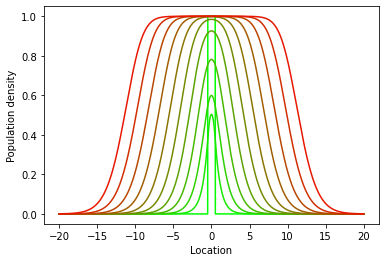

In [15]:
# first as density plot
import matplotlib.pyplot as plt
domain, results = out['domain'], out['results']
n = len(results)
for i in range(n):
  plt.plot(domain, results[i], color=(i/n,1-i/n,0))

plt.xlabel('Location')
plt.ylabel('Population density')
plt.show()

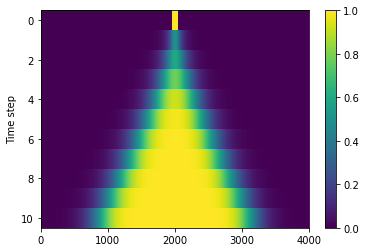

In [21]:
plt.imshow(results, cmap='viridis', interpolation='nearest',
           aspect='auto')
plt.colorbar()
plt.ylabel('Time step')
plt.show()